Key operations include:
- Loading multiple raw GBIF occurrence data files and reference species lists.
- Merging occurrence records with multimedia (image) URLs.
- capping maximum images per species
- statistics about the data

In [ ]:
import pandas as pd
import re

In [3]:
plant_species_list_txt = '/kaggle/input/species-lists-data/plant_list.txt' # source: https://www.researchgate.net/profile/Hatem-Taifour/publication/333223575_THE_PLANTS_OF_JORDAN_An_annotated_checklist/links/5ce2f3c692851c4eabb15c3c/THE-PLANTS-OF-JORDAN-An-annotated-checklist.pdf
insect_species_list_csv = '/kaggle/input/insects-species-list2/0064168-251120083545085.csv' # the species list from all insect occurrences in jordan and neighboring countries on gbif



# This is the regex we will use to clean ALL names.
# It finds the first two words (Genus species)
name_regex = re.compile(r'^([A-Z][a-z]+ [a-z]+)')

def clean_name(s):
    """Uses regex to extract just 'Genus species' from a full scientific name."""
    match = name_regex.search(str(s))
    if match:
        return match.group(1)
    return None


plant_species = set()
insect_species = set()

#plants
with open(plant_species_list_txt, 'r') as f:
    for line in f:
        clean_plant_name = clean_name(line)
        if clean_plant_name:
            plant_species.add(clean_plant_name.strip())
print(f"Loaded {len(plant_species)} unique plant species.")

#insects
df_insects = pd.read_csv(insect_species_list_csv, delimiter='\t')
df_insects_filtered = df_insects[
    (df_insects['taxonomicStatus'] == 'ACCEPTED') &
    (df_insects['taxonRank'] == 'SPECIES')
]

insect_species = set(df_insects_filtered['species'])

print(f"Loaded {len(insect_species)} unique insect species.")


#save sets as json
import json

with open('/kaggle/working/species-lists.json', 'w') as f:
    json.dump({
        'plants': list(plant_species),
        'insects': list(insect_species)
    }, f)


Loaded 2523 unique plant species.
Loaded 6789 unique insect species.


In [5]:
def process_occurrences(occurrence_file, species_set, name, save_dir='/kaggle/working'):
    """
    Processes a GBIF occurrence file and filters rows by a set of species.
    Returns:
        filtered_df: DataFrame with all relevant occurrences
        species_counts_df: DataFrame with occurrence counts per species
    Also saves both as CSVs to `save_dir` using the provided `name`.
    
    Parameters:
        occurrence_file (str): Path to the occurrence file (.txt or .csv)
        species_set (set): Set of valid species names
        name (str): Base name to save outputs (e.g., 'old_insect')
        save_dir (str): Directory to save CSVs (default '/kaggle/working')
    """
    print(f"--- Processing '{occurrence_file}' ---")
    relevant_chunks = []
    all_found_occurrences = []

    try:
        for chunk in pd.read_csv(
            occurrence_file,
            delimiter='\t',
            on_bad_lines='skip',
            low_memory=False,
            chunksize=50000
        ):
            # Keep only accepted species-level rows
            chunk = chunk[
                (chunk['taxonomicStatus'] == 'ACCEPTED') &
                (chunk['taxonRank'] == 'SPECIES') &
                (chunk['species'].notna())
            ].copy()

            if chunk.empty:
                continue

            # Filter rows by species set
            relevant_rows = chunk[chunk['species'].isin(species_set)]

            if not relevant_rows.empty:
                all_found_occurrences.extend(relevant_rows['species'].tolist())
                relevant_chunks.append(relevant_rows)

        if not relevant_chunks:
            print("No relevant occurrences found.")
            return pd.DataFrame(), pd.DataFrame()

        # Concatenate all relevant chunks
        filtered_df = pd.concat(relevant_chunks, ignore_index=True)

        # Create summary of occurrences per species
        species_counts_df = pd.Series(all_found_occurrences).value_counts().reset_index()
        species_counts_df.columns = ['species', 'occurrenceCount']

        
        print(f"Total occurrences: {len(filtered_df)}, Unique species: {len(species_counts_df)}")

        return filtered_df, species_counts_df

    except FileNotFoundError:
        print(f"File not found: {occurrence_file}")
        return pd.DataFrame(), pd.DataFrame()
    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame(), pd.DataFrame()


In [6]:
plant_occurrence = '/kaggle/input/dataset/plant-data/occurrence.txt'
new_plant_occurrence = '/kaggle/input/dataset/new-plant-data/occurrence.txt'
insect_occurrence = '/kaggle/input/dataset/insects-data/occurrence.txt'
new_insect_occurrence = '/kaggle/input/dataset/new-insect-data/occurrence.txt'

#i noticed that because the previous occurrences are filtered geographically using a polygon based on their coordiates that some of records in jordan for example don't have coordinates for all of them so i tested filtering some of them by country(jordan and neighboring)
plant_occurrence_2 = '/kaggle/input/data-filtered-by-countries/plant_data_2/occurrence.txt'
insect_occurrence_2 = '/kaggle/input/data-filtered-by-countries/insect_data_2/occurrence.txt'

# Process plant occurrences
plant_filtered_df, plant_summary_df = process_occurrences(
    plant_occurrence, 
    plant_species, 
    name='old_plant'
)

new_plant_filtered_df, new_plant_summary_df = process_occurrences(
    new_plant_occurrence, 
    plant_species, 
    name='new_plant'
)

plant_2_filtered_df, _ = process_occurrences(
    plant_occurrence_2, 
    plant_species, 
    name='plant2'
)

# Process insect occurrences
insect_filtered_df, insect_summary_df = process_occurrences(
    insect_occurrence, 
    insect_species, 
    name='old_insect'
)

new_insect_filtered_df, new_insect_summary_df = process_occurrences(
    new_insect_occurrence, 
    insect_species, 
    name='new_insect'
)

insect_2_filtered_df, _ = process_occurrences(
    insect_occurrence_2, 
    insect_species, 
    name='insect2'
)


--- Processing '/kaggle/input/dataset/plant-data/occurrence.txt' ---
Total occurrences: 96057, Unique species: 1934
--- Processing '/kaggle/input/dataset/new-plant-data/occurrence.txt' ---
Total occurrences: 197246, Unique species: 1532
--- Processing '/kaggle/input/data-filtered-by-countries/plant_data_2/occurrence.txt' ---
Total occurrences: 166681, Unique species: 2122
--- Processing '/kaggle/input/dataset/insects-data/occurrence.txt' ---
Total occurrences: 61326, Unique species: 3086
--- Processing '/kaggle/input/dataset/new-insect-data/occurrence.txt' ---
Total occurrences: 402202, Unique species: 2528
--- Processing '/kaggle/input/data-filtered-by-countries/insect_data_2/occurrence.txt' ---
Total occurrences: 57002, Unique species: 3844


In [9]:
def add_urls(occ_df, multimedia_file, gbif_col='gbifID', url_col='identifier'):
    """
    Adds a column to occ_df containing URLs from the multimedia file based on GBIF IDs.
    
    Parameters:
        occ_df (pd.DataFrame): Occurrence DataFrame (filtered)
        multimedia_file (str): Path to GBIF multimedia CSV file
        gbif_col (str): Column in occ_df containing GBIF IDs
        url_col (str): Column in multimedia CSV containing URLs (called 'identifier' in your file)
    
    Returns:
        pd.DataFrame: occ_df with a new 'url' column
    """
    media_df = pd.read_csv(multimedia_file, delimiter='\t', low_memory=False)
    media_df = media_df[[gbif_col, url_col]].drop_duplicates()
    merged_df = occ_df.merge(media_df, left_on=gbif_col, right_on=gbif_col, how='left')
    merged_df.rename(columns={url_col: 'url'}, inplace=True)
    
    return merged_df


In [10]:
# Plants
plant_multimedia_file = '/kaggle/input/dataset/plant-data/plant_multimedia.txt'
plant_2_multimedia_file = '/kaggle/input/data-filtered-by-countries/plant_data_2/multimedia.txt'
new_plant_multimedia_file = '/kaggle/input/dataset/new-plant-data/multimedia.txt'

plant_filtered_df = add_urls(plant_filtered_df, plant_multimedia_file)
new_plant_filtered_df = add_urls(new_plant_filtered_df, new_plant_multimedia_file)
plant_2_filtered_df = add_urls(plant_2_filtered_df, plant_2_multimedia_file)

# Insects
insect_multimedia_file = '/kaggle/input/dataset/insects-data/multimedia.txt'
new_insect_multimedia_file = '/kaggle/input/dataset/new-insect-data/multimedia.txt'
insect_2_multimedia_file = '/kaggle/input/data-filtered-by-countries/insect_data_2/multimedia.txt'

insect_filtered_df = add_urls(insect_filtered_df, insect_multimedia_file)
new_insect_filtered_df = add_urls(new_insect_filtered_df, new_insect_multimedia_file)
insect_2_filtered_df = add_urls(insect_2_filtered_df, insect_2_multimedia_file)

In [11]:
merged_plants_df = pd.concat([plant_2_filtered_df, new_plant_filtered_df], ignore_index=True)
merged_plants_df.drop_duplicates(subset=['gbifID'], inplace=True)

merged_insects_df = pd.concat([insect_2_filtered_df, new_insect_filtered_df], ignore_index=True)
merged_insects_df.drop_duplicates(subset=['gbifID'], inplace=True)

In [12]:
save_dir = '/kaggle/working'

# Plants
#plant_filtered_df.to_csv(f"{save_dir}/old_plant_filtered_occurrences.csv", index=False)
#plant_summary_df.to_csv(f"{save_dir}/old_plant_species_summary.csv", index=False)
#new_plant_filtered_df.to_csv(f"{save_dir}/new_plant_filtered_occurrences.csv", index=False)
#new_plant_summary_df.to_csv(f"{save_dir}/new_plant_species_summary.csv", index=False)

# Insects
#insect_filtered_df.to_csv(f"{save_dir}/old_insect_filtered_occurrences.csv", index=False)
#insect_summary_df.to_csv(f"{save_dir}/old_insect_species_summary.csv", index=False)
#new_insect_filtered_df.to_csv(f"{save_dir}/new_insect_filtered_occurrences.csv", index=False)
#new_insect_summary_df.to_csv(f"{save_dir}/new_insect_species_summary.csv", index=False)

#print("All filtered occurrences and species summaries saved successfully.")

In [14]:
print( merged_plants_df.shape)
print( merged_insects_df.shape)

(350521, 227)
(450549, 227)


In [15]:
def cap_occurrences(df, species_col='species', max_per_species=500, randomize=True):
    """
    Limits the number of rows per species to max_per_species.
    
    Parameters:
        df (pd.DataFrame): Input occurrence DataFrame
        species_col (str): Column with species names
        max_per_species (int): Maximum rows per species
        randomize (bool): If True, randomly select rows per species; otherwise take first rows
    
    Returns:
        pd.DataFrame: DataFrame with capped occurrences
    """
    if randomize:
        return df.groupby(species_col, group_keys=False).apply(
            lambda x: x.sample(n=min(len(x), max_per_species))
        ).reset_index(drop=True)
    else:
        return df.groupby(species_col, group_keys=False).apply(
            lambda x: x.head(max_per_species)
        ).reset_index(drop=True)


In [17]:
# Cap plant occurrences
merged_plants_df_capped = cap_occurrences(merged_plants_df, max_per_species=200)
# Cap insect occurrences
merged_insects_df_capped = cap_occurrences(merged_insects_df, max_per_species=200)

/tmp/ipykernel_47/4105653949.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(species_col, group_keys=False).apply(
/tmp/ipykernel_47/4105653949.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(species_col, group_keys=False).apply(


In [19]:
print( merged_plants_df_capped.shape)
print( merged_insects_df_capped.shape)

num_unique_p = merged_plants_df_capped['species'].nunique()
print(f"Number of unique plant species: {num_unique_p}")

num_unique_p = merged_insects_df_capped['species'].nunique()
print(f"Number of unique insect species: {num_unique_p}")

plants_counts = merged_plants_df_capped['species'].value_counts()
insects_counts = merged_insects_df_capped['species'].value_counts()

num_plants_10plus = (plants_counts >= 10).sum()
num_insects_10plus = (insects_counts >= 10).sum()

print(f"Number of plant species with at least 10 occurrences: {num_plants_10plus}")
print(f"Number of insect species with at least 10 occurrences: {num_insects_10plus}")

(179968, 227)
(145714, 227)
Number of unique plant species: 2148
Number of unique insect species: 4269
Number of plant species with at least 10 occurrences: 1858
Number of insect species with at least 10 occurrences: 1811


In [21]:
merged_plants_df_capped.to_csv(f"{save_dir}/plants_data.csv", index=False)
merged_insects_df_capped.to_csv(f"{save_dir}/insects_data.csv", index=False)

--- PLANTS DATASET STATISTICS ---
Total Species found: 2148
Total Images found: 179968
------------------------------
CRITERIA: Keeping species with >= 10 images
Eligible Species: 1858 (86.5%)
Eligible Images:  178577 (99.2%)
------------------------------
Dropped Species:  290 (less than 10 images)
Dropped Images:   1391
------------------------------
DISTRIBUTION (of Eligible Data):
   Min images per species: 10
   Max images per species: 200
   Avg images per species: 96.1
   Median images per species: 77.0


--- INSECTS DATASET STATISTICS ---
Total Species found: 4269
Total Images found: 145714
------------------------------
CRITERIA: Keeping species with >= 10 images
Eligible Species: 1811 (42.4%)
Eligible Images:  138468 (95.0%)
------------------------------
Dropped Species:  2458 (less than 10 images)
Dropped Images:   7246
------------------------------
DISTRIBUTION (of Eligible Data):
   Min images per species: 10
   Max images per species: 200
   Avg images per species: 76.5

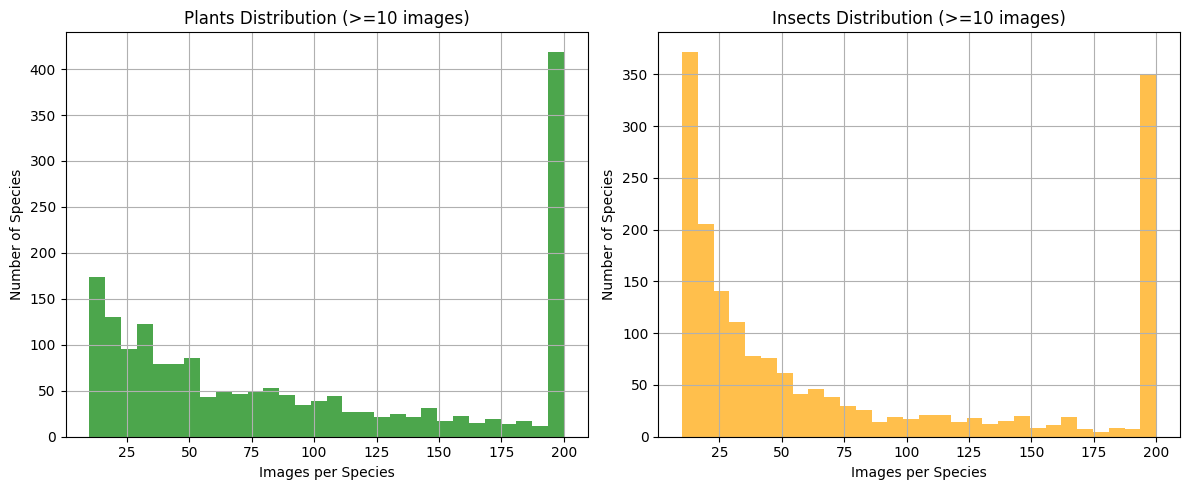

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_dataset_stats(df, name, threshold=10):
    print(f"--- {name.upper()} DATASET STATISTICS ---")
    
    counts = df['species'].value_counts()
    total_species = len(counts)
    total_images = len(df)
    
    # (>= 10 images)
    valid_species = counts[counts >= threshold]
    dropped_species = counts[counts < threshold]
    
    num_valid_species = len(valid_species)
    num_valid_images = valid_species.sum()
    
    num_dropped_species = len(dropped_species)
    num_dropped_images = dropped_species.sum()
    
    pct_species_kept = (num_valid_species / total_species) * 100
    pct_images_kept = (num_valid_images / total_images) * 100

    print(f"Total Species found: {total_species}")
    print(f"Total Images found: {total_images}")
    print("-" * 30)
    print(f"CRITERIA: Keeping species with >= {threshold} images")
    print(f"Eligible Species: {num_valid_species} ({pct_species_kept:.1f}%)")
    print(f"Eligible Images:  {num_valid_images} ({pct_images_kept:.1f}%)")
    print("-" * 30)
    print(f"Dropped Species:  {num_dropped_species} (less than 10 images)")
    print(f"Dropped Images:   {num_dropped_images}")
    print("-" * 30)
    print("DISTRIBUTION (of Eligible Data):")
    print(f"   Min images per species: {valid_species.min()}")
    print(f"   Max images per species: {valid_species.max()}")
    print(f"   Avg images per species: {valid_species.mean():.1f}")
    print(f"   Median images per species: {valid_species.median()}")
    print("\n")
    
    return valid_species


valid_plants = analyze_dataset_stats(merged_plants_df_capped, "Plants", threshold=10)
valid_insects = analyze_dataset_stats(merged_insects_df_capped, "Insects", threshold=10)


total_valid_images = valid_plants.sum() + valid_insects.sum()
total_valid_classes = len(valid_plants) + len(valid_insects)

print(f"=== TOTALS ===")
print(f"Total Classes: {total_valid_classes}")
print(f"Total Images:  {total_valid_images}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
valid_plants.hist(bins=30, color='green', alpha=0.7)
plt.title(f"Plants Distribution (>=10 images)")
plt.xlabel("Images per Species")
plt.ylabel("Number of Species")

plt.subplot(1, 2, 2)
valid_insects.hist(bins=30, color='orange', alpha=0.7)
plt.title(f"Insects Distribution (>=10 images)")
plt.xlabel("Images per Species")
plt.ylabel("Number of Species")

plt.tight_layout()
plt.show()

Starting Data Processing Pipeline...

Loaded 2523 unique plant species.
Loaded 1045 unique insect species.
--- Processing '/kaggle/input/dataset/plant-data/occurrence.txt' ---
Total occurrences: 96057, Unique species: 1934
--- Processing '/kaggle/input/dataset/new-plant-data/occurrence.txt' ---
Total occurrences: 197246, Unique species: 1532
--- Processing '/kaggle/input/dataset/insects-data/occurrence.txt' ---
Total occurrences: 34280, Unique species: 564
--- Processing '/kaggle/input/dataset/new-insect-data/occurrence.txt' ---
Total occurrences: 136001, Unique species: 409

Adding Multimedia URLs...

Merging and Deduplicating Datasets...
Total merged unique Plants DF: (277471, 227)
Total merged unique Insects DF: (163361, 227)

Downsampling occurrences...


/tmp/ipykernel_47/3000278444.py:156: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(species_col, group_keys=False).apply(
/tmp/ipykernel_47/3000278444.py:156: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(species_col, group_keys=False).apply(



Filtering datasets to retain STRICTLY 'JO' records...
Plants filtered: 170084 rows reduced to 2726 rows.
Insects filtered: 59373 rows reduced to 1580 rows.

Saving final capped and filtered datasets...


--- 5. Data Analysis ---


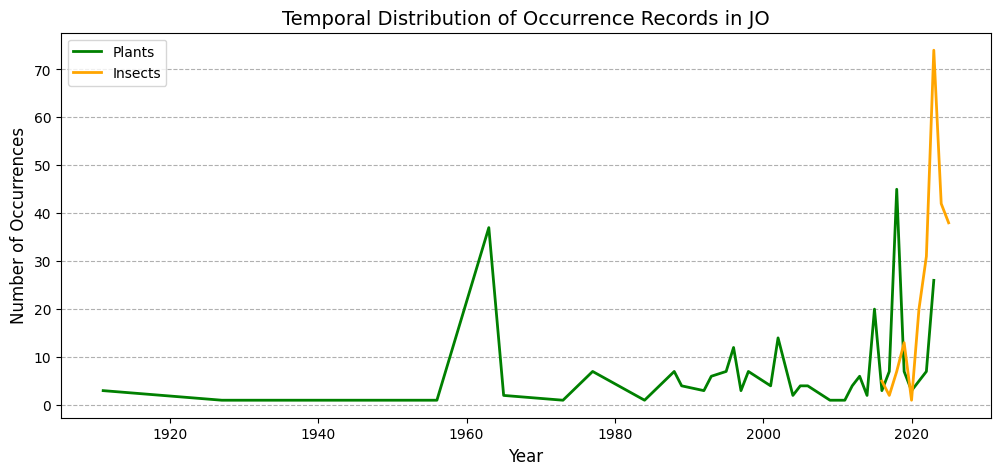


Top 10 Most Frequent Plant Species in JO:
 species
Retama raetam               53
Anchusa strigosa            46
Hyoscyamus aureus           43
Thymelaea hirsuta           39
Citrullus colocynthis       37
Gomphocarpus sinaicus       37
Calotropis procera          32
Nerium oleander             30
Pancratium sickenbergeri    26
Matthiola longipetala       26
Name: count, dtype: int64

Top 10 Most Frequent Insect Species in JO:
 species
Adesmia cancellata        180
Osmia centaureae           52
Osmia carbo                44
Poekilocerus bufonius      36
Hoplitis hemisphaerica     35
Trithemis arteriosa        32
Hoplitis hierichonica      31
Belenois aurota            28
Osmia lhotelleriei         27
Oiketicoides jordana       26
Name: count, dtype: int64


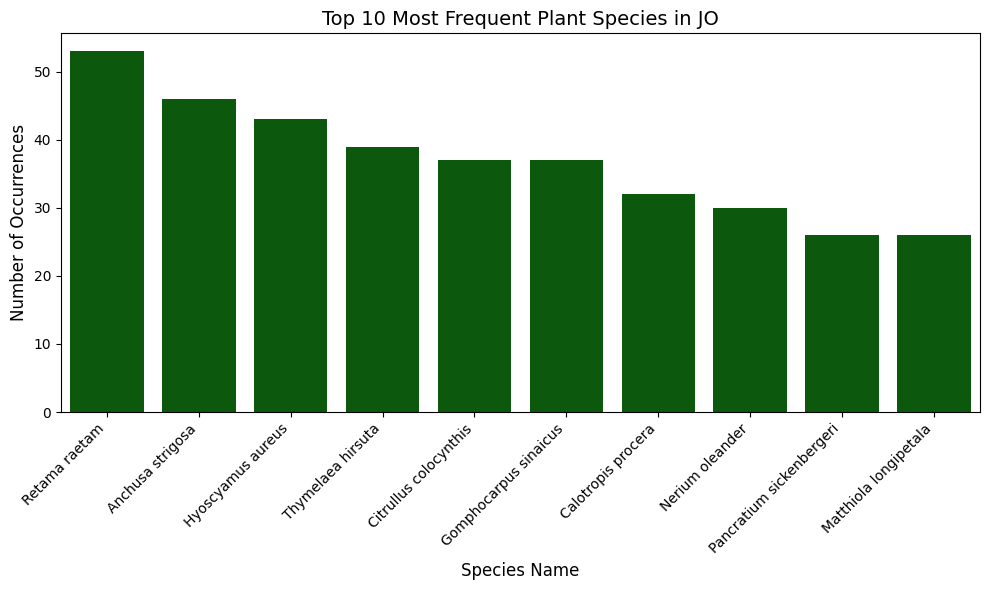

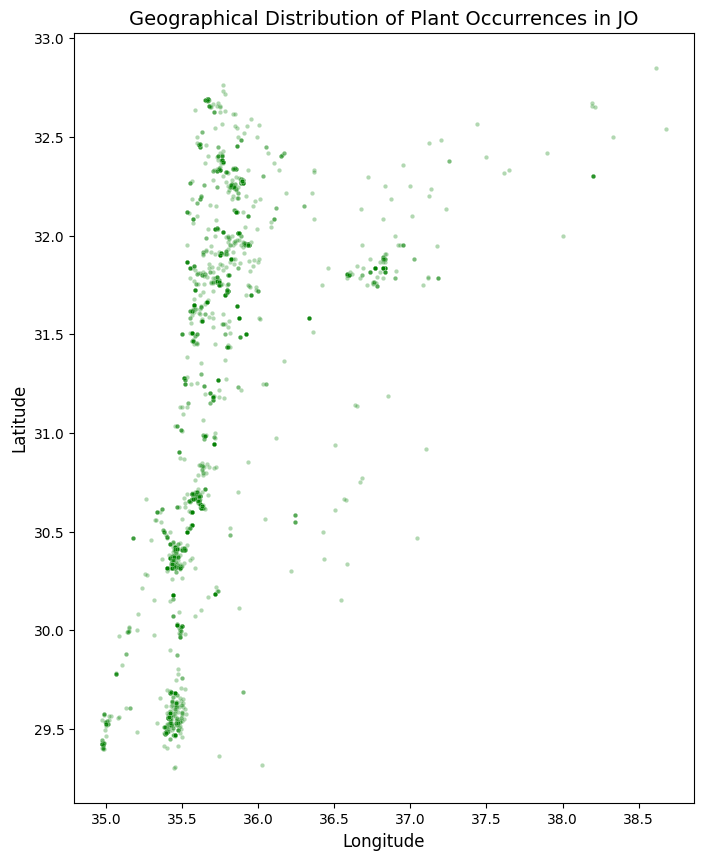


Data Processing and Analysis Complete.


In [16]:
import pandas as pd
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns

# --- File Paths and Global Settings ---
plant_species_list_txt = '/kaggle/input/species-lists-data/plant_list.txt'
insect_species_list_csv = '/kaggle/input/species-lists-data/insects.csv'

plant_occurrence = '/kaggle/input/dataset/plant-data/occurrence.txt'
new_plant_occurrence = '/kaggle/input/dataset/new-plant-data/occurrence.txt'
plant_multimedia_file = '/kaggle/input/dataset/plant-data/plant_multimedia.txt'
new_plant_multimedia_file = '/kaggle/input/dataset/new-plant-data/multimedia.txt'

insect_occurrence = '/kaggle/input/dataset/insects-data/occurrence.txt'
new_insect_occurrence = '/kaggle/input/dataset/new-insect-data/occurrence.txt'
insect_multimedia_file = '/kaggle/input/dataset/insects-data/multimedia.txt'
new_insect_multimedia_file = '/kaggle/input/dataset/new-insect-data/multimedia.txt'

save_dir = '/kaggle/working'
TARGET_COUNTRY_CODE = 'JO' # Focusing the study strictly on Jordan

# --- 1. Data Cleaning and Loading Functions ---

name_regex = re.compile(r'^([A-Z][a-z]+ [a-z]+)')

def clean_name(s):
    """Uses regex to extract just 'Genus species' from a full scientific name."""
    match = name_regex.search(str(s))
    if match:
        return match.group(1)
    return None

def load_species_sets():
    """Loads and cleans plant and insect species lists into sets."""
    plant_species = set()
    insect_species = set()

    # Load and clean Plant Species
    with open(plant_species_list_txt, 'r') as f:
        for line in f:
            clean_plant_name = clean_name(line)
            if clean_plant_name:
                plant_species.add(clean_plant_name.strip())

    # Load and filter Insect Species
    try:
        df_insects = pd.read_csv(insect_species_list_csv, delimiter='\t')
        df_insects_filtered = df_insects[
            (df_insects['taxonomicStatus'] == 'ACCEPTED') &
            (df_insects['taxonRank'] == 'SPECIES')]
        insect_species = set(df_insects_filtered['species'].dropna())
    except Exception as e:
        print(f"Error loading insect list: {e}")

    print(f"Loaded {len(plant_species)} unique plant species.")
    print(f"Loaded {len(insect_species)} unique insect species.")

    # Save the sets as JSON for record
    with open(f'{save_dir}/species-lists.json', 'w') as f:
        json.dump({
            'plants': list(plant_species),
            'insects': list(insect_species)
        }, f)

    return plant_species, insect_species

# --- 2. Occurrence Data Processing Function ---

def process_occurrences(occurrence_file, species_set, name, save_dir=save_dir):
    """
    Processes a GBIF occurrence file and filters rows by a set of species.
    Returns: filtered_df, species_counts_df.
    """
    print(f"--- Processing '{occurrence_file}' ---")
    relevant_chunks = []
    all_found_occurrences = []

    try:
        # Read file in chunks to handle large files efficiently
        for chunk in pd.read_csv(
            occurrence_file,
            delimiter='\t',
            on_bad_lines='skip',
            low_memory=False,
            chunksize=50000
        ):
            # Apply standard GBIF cleaning/filtering
            chunk = chunk[
                (chunk['taxonomicStatus'] == 'ACCEPTED') &
                (chunk['taxonRank'] == 'SPECIES') &
                (chunk['species'].notna())
            ].copy()

            if chunk.empty:
                continue

            # Filter rows by the specific species set
            relevant_rows = chunk[chunk['species'].isin(species_set)]

            if not relevant_rows.empty:
                all_found_occurrences.extend(relevant_rows['species'].tolist())
                relevant_chunks.append(relevant_rows)

        # Concatenate all relevant chunks
        if not relevant_chunks:
            print("No relevant occurrences found.")
            return pd.DataFrame(), pd.DataFrame()
            
        filtered_df = pd.concat(relevant_chunks, ignore_index=True)

        # Create summary of occurrences per species
        species_counts_df = pd.Series(all_found_occurrences).value_counts().reset_index()
        species_counts_df.columns = ['species', 'occurrenceCount']

        # Save interim summary files
        filtered_df.to_csv(f"{save_dir}/{name}_filtered_occurrences.csv", index=False)
        species_counts_df.to_csv(f"{save_dir}/{name}_species_summary.csv", index=False)
        
        print(f"Total occurrences: {len(filtered_df)}, Unique species: {len(species_counts_df)}")

        return filtered_df, species_counts_df

    except FileNotFoundError:
        print(f"File not found: {occurrence_file}")
        return pd.DataFrame(), pd.DataFrame()
    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame(), pd.DataFrame()

# --- 3. Multimedia URL Addition Function ---

def add_urls(occ_df, multimedia_file, gbif_col='gbifID', url_col='identifier'):
    """Adds a 'url' column to occ_df by merging with the multimedia file based on GBIF IDs."""
    if occ_df.empty:
        return occ_df
    try:
        media_df = pd.read_csv(multimedia_file, delimiter='\t', low_memory=False)
        media_df = media_df[[gbif_col, url_col]].drop_duplicates()
        merged_df = occ_df.merge(media_df, left_on=gbif_col, right_on=gbif_col, how='left')
        merged_df.rename(columns={url_col: 'url'}, inplace=True)
        return merged_df
    except Exception as e:
        print(f"Error adding URLs from {multimedia_file}: {e}")
        return occ_df.assign(url=None)

# --- 4. Occurrence Cap Function (Downsampling) ---

def cap_occurrences(df, species_col='species', max_per_species=500, randomize=True):
    """Limits the number of rows per species to max_per_species, with optional randomization."""
    if df.empty:
        return df
    if randomize:
        # Randomly select up to max_per_species rows per group
        return df.groupby(species_col, group_keys=False).apply(
            lambda x: x.sample(n=min(len(x), max_per_species), random_state=42)
        ).reset_index(drop=True)
    else:
        # Take the first max_per_species rows per group
        return df.groupby(species_col, group_keys=False).apply(
            lambda x: x.head(max_per_species)
        ).reset_index(drop=True)


# --- MAIN EXECUTION BLOCK ---

print("Starting Data Processing Pipeline...\n")

# A. Load Species Lists
plant_species, insect_species = load_species_sets()

# B. Process Occurrence Data (Old and New) - (Produces filtered_df and summary_df)
plant_filtered_df, plant_summary_df = process_occurrences(plant_occurrence, plant_species, name='old_plant')
new_plant_filtered_df, new_plant_summary_df = process_occurrences(new_plant_occurrence, plant_species, name='new_plant')
insect_filtered_df, insect_summary_df = process_occurrences(insect_occurrence, insect_species, name='old_insect')
new_insect_filtered_df, new_insect_summary_df = process_occurrences(new_insect_occurrence, insect_species, name='new_insect')

# C. Add Multimedia URLs
print("\nAdding Multimedia URLs...")
plant_filtered_df = add_urls(plant_filtered_df, plant_multimedia_file)
new_plant_filtered_df = add_urls(new_plant_filtered_df, new_plant_multimedia_file)
insect_filtered_df = add_urls(insect_filtered_df, insect_multimedia_file)
new_insect_filtered_df = add_urls(new_insect_filtered_df, new_insect_multimedia_file)

# D. Merge and Deduplicate Datasets
print("\nMerging and Deduplicating Datasets...")
merged_plants_df = pd.concat([plant_filtered_df, new_plant_filtered_df], ignore_index=True)
merged_plants_df.drop_duplicates(subset=['gbifID'], inplace=True)
merged_insects_df = pd.concat([insect_filtered_df, new_insect_filtered_df], ignore_index=True)
merged_insects_df.drop_duplicates(subset=['gbifID'], inplace=True)

print(f"Total merged unique Plants DF: {merged_plants_df.shape}")
print(f"Total merged unique Insects DF: {merged_insects_df.shape}")

# E. Cap Occurrences (Downsampling)
print("\nDownsampling occurrences...")
merged_plants_df_capped = cap_occurrences(merged_plants_df, max_per_species=400)
merged_insects_df_capped = cap_occurrences(merged_insects_df, max_per_species=500)

# F. STRICT GEOGRAPHICAL FILTERING (Removing all non-Jordan records)
# This step ensures the final analysis focuses only on the target country (JO)
print(f"\nFiltering datasets to retain STRICTLY '{TARGET_COUNTRY_CODE}' records...")

# Filter Plants Data
initial_plant_count = len(merged_plants_df_capped)
merged_plants_df_capped = merged_plants_df_capped[
    merged_plants_df_capped['countryCode'] == TARGET_COUNTRY_CODE
]
final_plant_count = len(merged_plants_df_capped)
print(f"Plants filtered: {initial_plant_count} rows reduced to {final_plant_count} rows.")

# Filter Insects Data
initial_insect_count = len(merged_insects_df_capped)
merged_insects_df_capped = merged_insects_df_capped[
    merged_insects_df_capped['countryCode'] == TARGET_COUNTRY_CODE
]
final_insect_count = len(merged_insects_df_capped)
print(f"Insects filtered: {initial_insect_count} rows reduced to {final_insect_count} rows.")


# G. Final Filtered Dataframe Saving
print("\nSaving final capped and filtered datasets...")
merged_plants_df_capped.to_csv(f"{save_dir}/final_merged_plants_capped_JO.csv", index=False)
merged_insects_df_capped.to_csv(f"{save_dir}/final_merged_insects_capped_JO.csv", index=False)


# --- 5. Data Analysis and Visualization (Using JO-only data) ---

print("\n\n--- 5. Data Analysis ---")

## 5.1 Temporal Distribution Analysis

merged_plants_df_capped['eventDate'] = pd.to_datetime(merged_plants_df_capped['eventDate'], errors='coerce')
merged_insects_df_capped['eventDate'] = pd.to_datetime(merged_insects_df_capped['eventDate'], errors='coerce')

plant_years = merged_plants_df_capped['eventDate'].dt.year.dropna().astype(int)
insect_years = merged_insects_df_capped['eventDate'].dt.year.dropna().astype(int)

plt.figure(figsize=(12, 5))
plant_years.value_counts().sort_index().plot(kind='line', label='Plants', color='green', linewidth=2)
insect_years.value_counts().sort_index().plot(kind='line', label='Insects', color='orange', linewidth=2)
plt.title(f'Temporal Distribution of Occurrence Records in {TARGET_COUNTRY_CODE}', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()
# 


## 5.2 Most Frequent Species Analysis

top_10_plants = merged_plants_df_capped['species'].value_counts().nlargest(10)
top_10_insects = merged_insects_df_capped['species'].value_counts().nlargest(10)

print(f"\nTop 10 Most Frequent Plant Species in {TARGET_COUNTRY_CODE}:\n", top_10_plants)
print(f"\nTop 10 Most Frequent Insect Species in {TARGET_COUNTRY_CODE}:\n", top_10_insects)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_plants.index, y=top_10_plants.values, color='darkgreen')
plt.title(f'Top 10 Most Frequent Plant Species in {TARGET_COUNTRY_CODE}', fontsize=14)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Species Name', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# 


## 5.3 Geographical Distribution (Visualizing the Clean Data)

jordan_plants = merged_plants_df_capped[['decimalLatitude', 'decimalLongitude']].dropna()

plt.figure(figsize=(8, 10))
sns.scatterplot(
    x=jordan_plants['decimalLongitude'],
    y=jordan_plants['decimalLatitude'],
    alpha=0.3,
    s=10,
    color='green'
)
plt.title(f'Geographical Distribution of Plant Occurrences in {TARGET_COUNTRY_CODE}', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.show()
# 


print("\nData Processing and Analysis Complete.")